In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load CFAIR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 260s 2us/step


In [3]:
# standard cnn
def build_standard_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [4]:
# cnn with depthwise swparable convolutions
def build_depthwise_cnn():
    model = models.Sequential([
        layers.SeparableConv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.AveragePooling2D((2, 2)),

        layers.SeparableConv2D(64, (3, 3), activation='relu', padding='same'),
        layers.AveragePooling2D((2, 2)),

        layers.SeparableConv2D(128, (3, 3), activation='relu', padding='same'),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [5]:
# cnn with dialated convolutions
def build_dilated_cnn():
    model = models.Sequential([
        layers.Conv2D(
            32, (3, 3),
            activation='relu',
            padding='same',
            dilation_rate=2,
            input_shape=(32, 32, 3)
        ),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            64, (3, 3),
            activation='relu',
            padding='same',
            dilation_rate=2
        ),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            128, (3, 3),
            activation='relu',
            padding='same',
            dilation_rate=2
        ),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [6]:
# training
def compile_and_train(model, name, epochs=10):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f"\nTraining {name} model...")
    history = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=64,
        validation_split=0.2  ,
        verbose=1
    )
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name} Test Accuracy: {test_acc:.4f}")

    return history, test_acc

In [7]:
models_dict = {
    'Standard Conv' : build_standard_cnn(),
    'Depthwise Conv' : build_depthwise_cnn(),
    'Dilated Conv' : build_dilated_cnn()
}

histories = {}
for name, model in models_dict.items():
  histories[name] = compile_and_train(model, name)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(



Training Standard Conv model...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3198 - loss: 1.8120 - val_accuracy: 0.4109 - val_loss: 1.5992
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4441 - loss: 1.5098 - val_accuracy: 0.4819 - val_loss: 1.4137
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5096 - loss: 1.3540 - val_accuracy: 0.5378 - val_loss: 1.2885
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5449 - loss: 1.2551 - val_accuracy: 0.5253 - val_loss: 1.3482
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5798 - loss: 1.1686 - val_accuracy: 0.5986 - val_loss: 1.1342
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6095 - loss: 1.0951 - val_accuracy: 0.6036 - val_loss: 1.1015
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6266 - loss: 1.0477 - val_accuracy: 0.6254 - val_loss: 1.0543
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6457

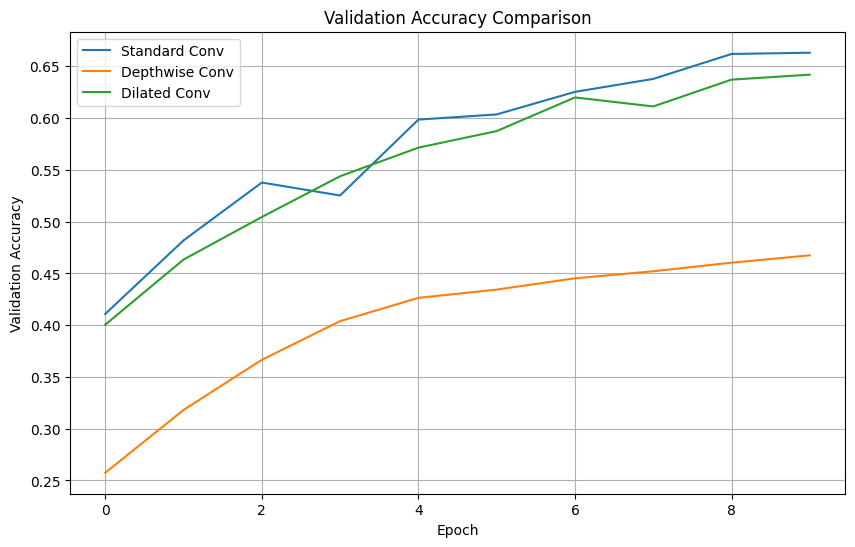

In [8]:
# plot acciracy comparison
plt.figure(figsize=(10, 6))

for name, (history, test_acc) in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()